In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import sklearn.metrics as sm 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster  # Import the fcluster function
from scipy.cluster.hierarchy import dendrogram
from scipy.spatial import distance


In [2]:
# dataframe
all4_2_gtsB_gtsD_clusters = pd.read_csv('consensus_quanti_variables_2_3_gtsB_gtsD_final.csv')
print(all4_2_gtsB_gtsD_clusters.shape)
print(all4_2_gtsB_gtsD_clusters.head())
print(all4_2_gtsB_gtsD_clusters.isnull().sum())
print(all4_2_gtsB_gtsD_clusters.shape)
print(all4_2_gtsB_gtsD_clusters.info())

(135, 10)
   gene  cluster           variable     v.test  mean_in_cluster  overall_mean  \
0  gtsB        1  Substitution rate -10.892007         8.958076    142.645832   
1  gtsB        1  A-T-Substitutions  -6.579562         0.033778      0.615609   
2  gtsB        1  A-C-Substitutions  -8.040358         0.152136      4.587909   
3  gtsB        1  A-G-Substitutions  -7.540725         0.258111     11.563127   
4  gtsB        1  T-A-Substitutions  -6.457394         0.046761      0.636377   

   sd_in_cluster  overall_sd       p.value  n_in_cluster  
0      18.075785  178.419785  0.000000e+00           103  
1       0.096341    1.285463  4.720000e-11           103  
2       0.466857    8.019610  8.880000e-16           103  
3       1.135209   21.793016  4.660000e-14           103  
4       0.142305    1.327308  1.070000e-10           103  
gene               0
cluster            0
variable           0
v.test             0
mean_in_cluster    0
overall_mean       0
sd_in_cluster      0
ov

In [3]:
print(all4_2_gtsB_gtsD_clusters.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gene             135 non-null    object 
 1   cluster          135 non-null    int64  
 2   variable         135 non-null    object 
 3   v.test           135 non-null    float64
 4   mean_in_cluster  135 non-null    float64
 5   overall_mean     135 non-null    float64
 6   sd_in_cluster    135 non-null    float64
 7   overall_sd       135 non-null    float64
 8   p.value          135 non-null    float64
 9   n_in_cluster     135 non-null    int64  
dtypes: float64(6), int64(2), object(2)
memory usage: 10.7+ KB
None


In [4]:
all4_2_gtsB_gtsD_clusters['cluster'] = all4_2_gtsB_gtsD_clusters['cluster'].astype('str')

In [5]:
##filtering by gene, first gtsB

filtered_gtsBclusters_2_4 = all4_2_gtsB_gtsD_clusters[all4_2_gtsB_gtsD_clusters['gene'] == 'gtsB']  
print(filtered_gtsBclusters_2_4.shape)

(75, 10)


In [7]:
##n sizes per cluster gtsB
n_number= [103,44,17,23,13]


In [8]:
fixed_colors = {'A-C-Substitutions':'#c6ae2f','A-G-Substitutions':'#6a71eb','A-T-Substitutions':'#59b642','C-A-Substitutions':'#b05acf','C-G-Substitutions':'#959e36','C-T-Substitutions':'#d248ad','G-A-Substitutions':'#45b479','G-C-Substitutions':'#d83f86','G-T-Substitutions':'#6f9445','T-A-Substitutions':'#6b5ebd','T-C-Substitutions':'#d56625','T-G-Substitutions':'#5387cf','Substitution rate':'blue','Transitions':'maroon','Transversions':'orchid'
               }

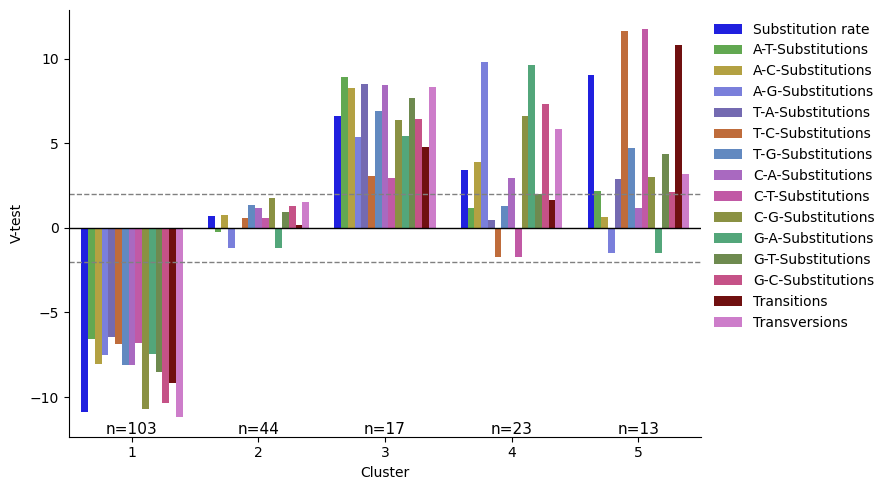

In [9]:
fig = plt.figure(figsize=(9, 5))

    # Creating the bar plot
sns.barplot(data=filtered_gtsBclusters_2_4 , x='cluster', y='v.test', hue='variable', palette=fixed_colors, linewidth=10)

# Set labels and title
plt.xlabel('Cluster')
plt.ylabel('V-test')
plt.title('')

# Adding n number under x-axis labels
for i, v in enumerate(n_number):
    plt.text(i, -12.2, f'n={v}', ha='center', fontsize=11, color='black')

# legend position to the right without overlapping
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Variables', ncol=1)


# Add a black line at y=0
plt.axhline(0, color='black', linewidth=1)

plt.axhline(2, color='gray', linestyle='--', linewidth=1)
plt.axhline(-2, color='gray', linestyle='--', linewidth=1)

# Remove borders around the graph
sns.despine()

# Remove legend border
plt.legend(frameon=False, bbox_to_anchor=(1, 1), fontsize=10)

plt.tight_layout()  # Adjust layout

# Save to PNG
plt.savefig('gtsB_barplot_2_3_4cluster_consensus_final_r2.png', dpi=1000)
plt.show()  
    

In [10]:
##filtering by gene, then gtsD

filtered_gtsDclusters_2_4all = all4_2_gtsB_gtsD_clusters[all4_2_gtsB_gtsD_clusters['gene'] == 'gtsD']  
print(filtered_gtsDclusters_2_4all.shape)

(60, 10)


In [11]:
##n sizes per cluster gtsD
n_number= [120,72,55,17]


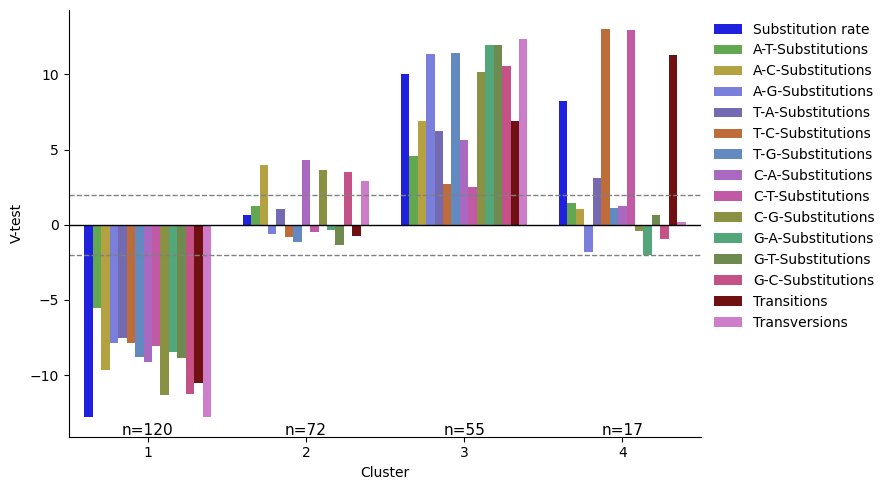

In [13]:
fig = plt.figure(figsize=(9, 5))  

# Creating the bar plot
sns.barplot(data=filtered_gtsDclusters_2_4all, x='cluster', y='v.test', hue='variable', palette=fixed_colors, linewidth=2)

# Set labels and title
plt.xlabel('Cluster')
plt.ylabel('V-test')
plt.title('')

# Adding n number under x-axis labels
for i, v in enumerate(n_number):
    plt.text(i, -14, f'n={v}', ha='center', fontsize=11, color='black')

# Set legend position to the right without overlapping
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Variables', ncol=1)


# Add a black line at y=0
plt.axhline(0, color='black', linewidth=1)

plt.axhline(2, color='gray', linestyle='--', linewidth=1)
plt.axhline(-2, color='gray', linestyle='--', linewidth=1)

# Remove borders around the graph
sns.despine()

# Remove legend border
plt.legend(frameon=False, bbox_to_anchor=(1, 1), fontsize=10)

plt.tight_layout()  # Adjust layout

# Saving PNG
plt.savefig('gtsD_barplot_2_3_4clusters_consensus_r2.png', dpi=1000)
plt.show()  
    